# 06 — Machine-Learning Model Comparison

## Objective

Evaluate whether machine-learning models improve 15-minute-ahead
industrial energy forecasts relative to the strongest naive baseline.

Notebook 05 identified the persistence forecast:

`Usage(t) = Usage(t-1)`

as the strongest baseline using expanding-window walk-forward validation.

Baseline performance:

- Mean MAE: 5.99 kWh
- Mean RMSE: 13.25 kWh
- Mean R²: 0.825

All machine-learning models will be evaluated using the same temporal
folds.

The December 2018 test period remains untouched.

In [1]:
#imports
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.base import clone

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder
)

from sklearn.linear_model import (
    LinearRegression,
    Ridge
)

from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor
)

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from xgboost import XGBRegressor

In [2]:
!pip install xgboost

In [3]:
#Loading the golden table
con = duckdb.connect("Steel_energy.duckdb")

In [4]:
df = con.sql("""
SELECT *
FROM gold_energy_features
ORDER BY timestamp
""").df()

In [5]:
df = df.sort_values(
    "timestamp"
).reset_index(drop=True)

In [6]:
df.head()

,timestamp,usage_kwh,hour,month,day_of_week,week_status,load_type,usage_15min_ago,usage_1h_ago,usage_lag_96,avg_usage_previous_hour
0,2018-01-01 00:00:00,3.42,0,1,Monday,Weekday,Light_Load,NaN,NaN,NaN,NaN
1,2018-01-01 00:15:00,3.17,0,1,Monday,Weekday,Light_Load,3.42,NaN,NaN,3.4200
2,2018-01-01 00:30:00,4.00,0,1,Monday,Weekday,Light_Load,3.17,NaN,NaN,3.2950
3,2018-01-01 00:45:00,3.24,0,1,Monday,Weekday,Light_Load,4.00,NaN,NaN,3.5300
4,2018-01-01 01:00:00,3.31,1,1,Monday,Weekday,Light_Load,3.24,3.42,NaN,3.4575


In [7]:
df["timestamp"].min(), df["timestamp"].max()

(Timestamp('2018-01-01 00:00:00'), Timestamp('2018-12-31 23:45:00'))

In [11]:
#Defining the features
#Assuming load_type known before 15-min forecast
#if not true it must be removed
#timestamp not needed as feature
#day, month, hour, weekstatus more informative

numeric_features = [
    "usage_15min_ago",
    "usage_1h_ago",
    "usage_lag_96",
    "avg_usage_previous_hour",
    "hour",
    "month"
]
categorical_features = [
    "day_of_week",
    "week_status",
    "load_type"
]
feature_columns = (
    numeric_features
    +
    categorical_features
)

target = "usage_kwh"

In [12]:
#Handle feature-related NULLs
#Historical features naturally create NULLS near the beginning
#usage_lag_96 cannot exist during first 96 observations
#these rows are not bad data, but can't be used
#we clean them up
df[
    feature_columns
].isna().sum()

usage_15min_ago             1
usage_1h_ago                4
usage_lag_96               96
avg_usage_previous_hour     1
hour                        0
month                       0
day_of_week                 0
week_status                 0
load_type                   0
dtype: int64

In [13]:
model_df = df.dropna(
    subset=feature_columns + [target]
).copy()

In [14]:
df.shape, model_df.shape

((35040, 11), (34944, 11))

In [15]:
#Preprocessing
#Linear model different from tree-model
#Ridge needs scaling of numerical features
#Tree-models do not need scaling
linear_preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numeric_features
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_features
        )
    ]
)
tree_preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            "passthrough",
            numeric_features
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_features
        )
    ]
)

In [16]:
#We will use pipelines
#preprocessing learns transformation only from the training portion o feach walk-forward fold
#leakage avoided
#training fold used for preprocessing/transformations
#validation vold used for prediction with transformations learnend from training fold

In [17]:
#Defining candidate models
#linear regression. useful to check whether the problem requires nonlinear models
#Ridge = linear regression + regularization. useful when predictors are correlated
#random forest = many decorrelated decision trees averaged together. captures nonlinear relationships, feature interactions
#Gradient boosting = sequentially added trees to improve existing model errors
#XGBoost = advanced gradient boosting implementation with regularization

#We create the model pipelines
models = {
    
    "Linear Regression": Pipeline([
        (
            "preprocessor",
            linear_preprocessor
        ),
        (
            "model",
            LinearRegression()
        )
    ]),
    
    
    "Ridge": Pipeline([
        (
            "preprocessor",
            linear_preprocessor
        ),
        (
            "model",
            Ridge(
                alpha=1.0
            )
        )
    ]),
    
    
    "Random Forest": Pipeline([
        (
            "preprocessor",
            tree_preprocessor
        ),
        (
            "model",
            RandomForestRegressor(
                n_estimators=100,
                random_state=42,
                n_jobs=-1
            )
        )
    ]),
    
    
    "Gradient Boosting": Pipeline([
        (
            "preprocessor",
            tree_preprocessor
        ),
        (
            "model",
            GradientBoostingRegressor(
                random_state=42
            )
        )
    ]),
    
    
    "XGBoost": Pipeline([
        (
            "preprocessor",
            tree_preprocessor
        ),
        (
            "model",
            XGBRegressor(
                objective="reg:squarederror",
                random_state=42,
                n_jobs=-1,
                verbosity=0
            )
        )
    ])
}

In [18]:
#We determine which model family is promising. Then we spend time tuning the best candidates

In [19]:
#Defining the metrics
def evaluate_forecast(
    y_true,
    y_pred
):
    
    mae = mean_absolute_error(
        y_true,
        y_pred
    )
    
    rmse = np.sqrt(
        mean_squared_error(
            y_true,
            y_pred
        )
    )
    
    r2 = r2_score(
        y_true,
        y_pred
    )
    
    return {
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    }

In [20]:
#defining training folds
#same exact folds must be used for all the models
folds = [
    ("2018-05-01", "2018-06-01"),
    ("2018-06-01", "2018-07-01"),
    ("2018-07-01", "2018-08-01"),
    ("2018-08-01", "2018-09-01"),
    ("2018-09-01", "2018-10-01"),
    ("2018-10-01", "2018-11-01"),
    ("2018-11-01", "2018-12-01"),
]

In [21]:
#December remains untouched

In [22]:
#Walk-forward model comparison
#including the baseline model as well
#clone()? creates a fresh unfitted version of the pipeline for each fold
#old trained model won't be reused
results = []

for fold_number, (
    val_start,
    val_end
) in enumerate(
    folds,
    start=1
):

    # -------------------------
    # Define temporal split
    # -------------------------
    
    train = model_df[
        model_df["timestamp"] < val_start
    ].copy()

    val = model_df[
        (
            model_df["timestamp"] >= val_start
        )
        &
        (
            model_df["timestamp"] < val_end
        )
    ].copy()


    X_train = train[
        feature_columns
    ]

    y_train = train[
        target
    ]


    X_val = val[
        feature_columns
    ]

    y_val = val[
        target
    ]


    # -------------------------
    # Persistence benchmark
    # -------------------------
    
    persistence_pred = val[
        "usage_15min_ago"
    ]

    metrics = evaluate_forecast(
        y_val,
        persistence_pred
    )

    results.append({
        "fold": fold_number,
        "validation_month": val_start,
        "model": "Persistence t-1",
        "train_rows": len(train),
        "validation_rows": len(val),
        **metrics
    })


    # -------------------------
    # Machine-learning models
    # -------------------------

    for model_name, pipeline in models.items():

        model = clone(
            pipeline
        )

        model.fit(
            X_train,
            y_train
        )

        predictions = model.predict(
            X_val
        )

        metrics = evaluate_forecast(
            y_val,
            predictions
        )

        results.append({
            "fold": fold_number,
            "validation_month": val_start,
            "model": model_name,
            "train_rows": len(train),
            "validation_rows": len(val),
            **metrics
        })

In [24]:
#individual fold results
results_df = pd.DataFrame(
    results
)
results_df

,fold,validation_month,model,train_rows,validation_rows,MAE,RMSE,R2
0,1,2018-05-01,Persistence t-1,11424,2976,6.322833,14.310939,0.822108
1,1,2018-05-01,Linear Regression,11424,2976,7.501483,13.410729,0.843784
2,1,2018-05-01,Ridge,11424,2976,7.501804,13.410873,0.843781
3,1,2018-05-01,Random Forest,11424,2976,5.643080,11.764211,0.879788
4,1,2018-05-01,Gradient Boosting,11424,2976,6.304975,12.090835,0.873021
5,1,2018-05-01,XGBoost,11424,2976,5.630207,11.655982,0.881990
6,2,2018-06-01,Persistence t-1,14400,2880,5.579962,12.700826,0.812621
7,2,2018-06-01,Linear Regression,14400,2880,6.645297,11.814060,0.837873
8,2,2018-06-01,Ridge,14400,2880,6.645637,11.814247,0.837868
9,2,2018-06-01,Random Forest,14400,2880,5.033495,10.435378,0.873505


In [25]:
#Summarizing across time
#this table tells us which model performs best on average across future months
model_summary = (
    results_df
    .groupby("model")
    .agg(
        MAE_mean=("MAE", "mean"),
        MAE_std=("MAE", "std"),
        RMSE_mean=("RMSE", "mean"),
        RMSE_std=("RMSE", "std"),
        R2_mean=("R2", "mean"),
        R2_std=("R2", "std")
    )
    .sort_values(
        "MAE_mean"
    )
)

model_summary

,MAE_mean,MAE_std,RMSE_mean,RMSE_std,R2_mean,R2_std
model,,,,,,
XGBoost,5.059619,0.641519,10.429373,0.942904,0.891210,0.011223
Random Forest,5.088596,0.719545,10.450835,1.109740,0.890917,0.012753
Gradient Boosting,5.648993,0.754126,10.769329,1.081093,0.884214,0.011807
Persistence t-1,5.986253,0.846897,13.249100,1.203816,0.824766,0.014016
Linear Regression,6.985576,0.785516,12.419978,1.170136,0.846163,0.011270
Ridge,6.985853,0.785518,12.420153,1.170146,0.846158,0.011270


In [26]:
#quantifying improvement oover persistence
persistence_mae = model_summary.loc[
    "Persistence t-1",
    "MAE_mean"
]

In [27]:
model_summary[
    "MAE_improvement_vs_persistence_pct"
] = (
    (
        persistence_mae
        -
        model_summary["MAE_mean"]
    )
    /
    persistence_mae
    *
    100
)

In [28]:
model_summary

,MAE_mean,MAE_std,RMSE_mean,RMSE_std,R2_mean,R2_std,MAE_improvement_vs_persistence_pct
model,,,,,,,
XGBoost,5.059619,0.641519,10.429373,0.942904,0.891210,0.011223,15.479362
Random Forest,5.088596,0.719545,10.450835,1.109740,0.890917,0.012753,14.995312
Gradient Boosting,5.648993,0.754126,10.769329,1.081093,0.884214,0.011807,5.633912
Persistence t-1,5.986253,0.846897,13.249100,1.203816,0.824766,0.014016,0.000000
Linear Regression,6.985576,0.785516,12.419978,1.170136,0.846163,0.011270,-16.693624
Ridge,6.985853,0.785518,12.420153,1.170146,0.846158,0.011270,-16.698255


In [29]:
#sorting by MAE
model_summary = model_summary.sort_values(
    "MAE_mean"
)

model_summary

,MAE_mean,MAE_std,RMSE_mean,RMSE_std,R2_mean,R2_std,MAE_improvement_vs_persistence_pct
model,,,,,,,
XGBoost,5.059619,0.641519,10.429373,0.942904,0.891210,0.011223,15.479362
Random Forest,5.088596,0.719545,10.450835,1.109740,0.890917,0.012753,14.995312
Gradient Boosting,5.648993,0.754126,10.769329,1.081093,0.884214,0.011807,5.633912
Persistence t-1,5.986253,0.846897,13.249100,1.203816,0.824766,0.014016,0.000000
Linear Regression,6.985576,0.785516,12.419978,1.170136,0.846163,0.011270,-16.693624
Ridge,6.985853,0.785518,12.420153,1.170146,0.846158,0.011270,-16.698255


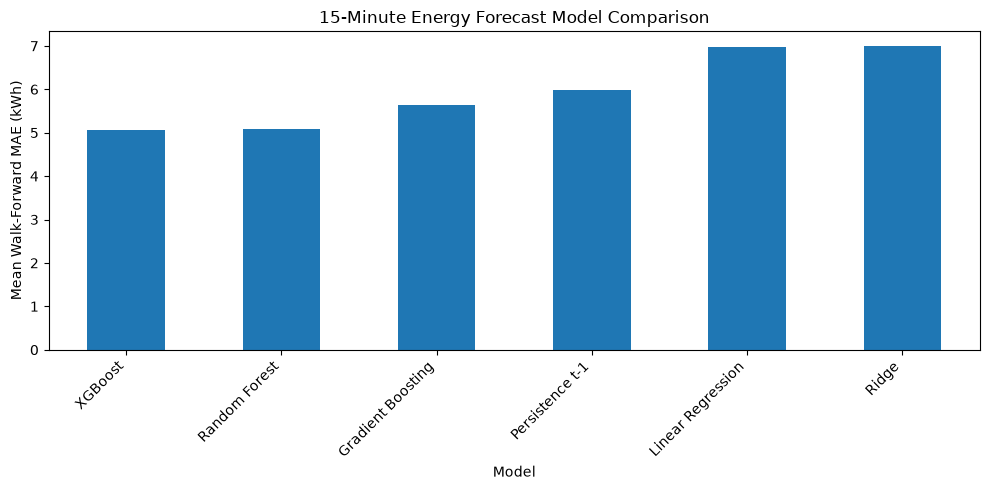

In [30]:
#plotting average model performance
model_summary[
    "MAE_mean"
].plot(
    kind="bar",
    figsize=(10, 5)
)

plt.ylabel(
    "Mean Walk-Forward MAE (kWh)"
)

plt.xlabel(
    "Model"
)

plt.title(
    "15-Minute Energy Forecast Model Comparison"
)

plt.xticks(
    rotation=45,
    ha="right"
)

plt.tight_layout()

plt.show()

In [31]:
#model stability through time
monthly_mae = results_df.pivot(
    index="validation_month",
    columns="model",
    values="MAE"
)

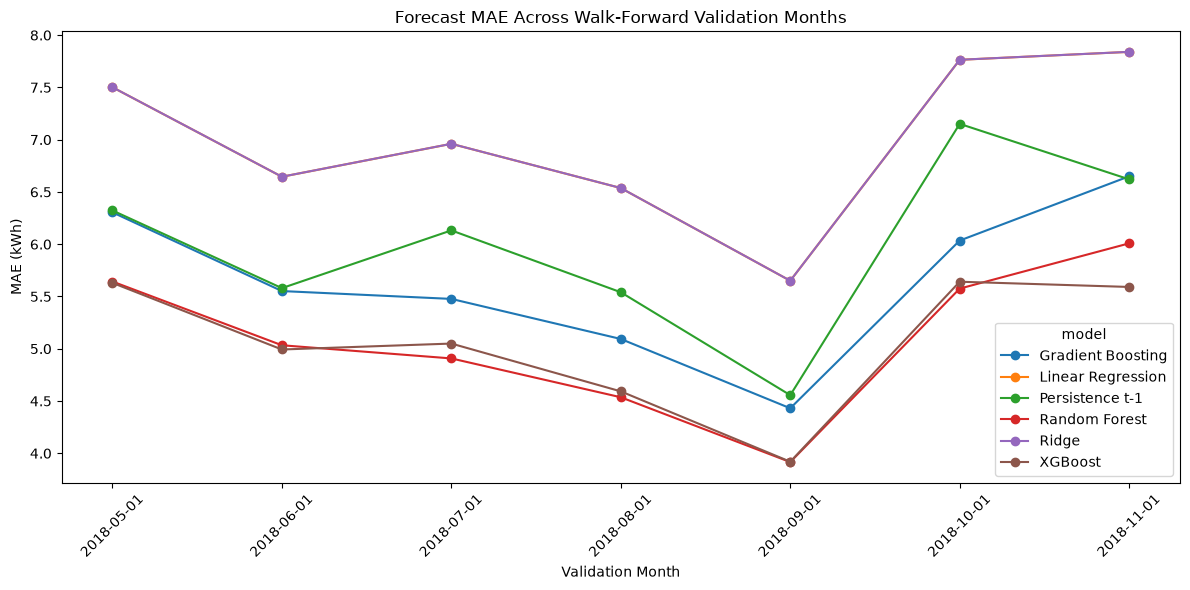

In [32]:
monthly_mae.plot(
    figsize=(12, 6),
    marker="o"
)

plt.ylabel(
    "MAE (kWh)"
)

plt.xlabel(
    "Validation Month"
)

plt.title(
    "Forecast MAE Across Walk-Forward Validation Months"
)

plt.xticks(
    rotation=45
)

plt.tight_layout()

plt.show()

In [39]:
#we want ideally low standard deviation
#sudden degradation can suggest process drift, operational change, seasonal change, sensor changes, different production regime
#we need to inspect temporal performance. average perfomance can hide instability

In [38]:
#determine the best ML model
ml_summary = model_summary.drop(
    index="Persistence t-1"
)

best_model_name = (
    ml_summary["MAE_mean"]
    .idxmin()
)

best_model_name






'XGBoost'

In [36]:
best_model_mae = (
    ml_summary.loc[
        best_model_name,
        "MAE_mean"
    ]
)
best_model_mae


np.float64(5.059619332001632)

In [37]:
best_improvement = (
    ml_summary.loc[
        best_model_name,
        "MAE_improvement_vs_persistence_pct"
    ]
)

best_improvement

np.float64(15.479361506163874)

Using historical energy, calendar, and operational information reduces average absolute forecast error by about 15.5% relative to simply assuming the next 15 minutes will equal the previous 15 minutes.

XGBoost and Random Forest are the two strongest candidate model families, with XGBoost producing the lowest average MAE and slightly lower variability across folds. Their performance is sufficiently close that both should remain candidates for the next stage.

Their difference is tiny, we can't say that XGBoost is better than RF.

One interesting observation:
with persistence we have MAE 5.99 and RMSE 13.25, while with linear we have MAE 6.99 and RMSE 12.42.
    This means linear regression makes a larger typical absolute error, but it seems to avoid some of the very large errors that hurt persistence. RMSE squares error, large errors penalize heavily the model. Our primary objective is MAE.
        Ridge and linear regression are substntially identical, so coefficient shrinkage did not improve performance.
            The monthly plot is interesting too. Nearly everything gets better around september and worse around october/november. 
                since it is not model dependent, this suggest a change in the underlying data/process, rather than one algorithm failing. 

# Model Comparison Conclusions

All candidate models were evaluated using the same expanding-window
walk-forward validation protocol used for the naive forecasting
baselines.

The 15-minute persistence forecast provided a strong benchmark with
a mean MAE of 5.99 kWh.

Tree-based ensemble models outperformed the persistence benchmark.

XGBoost produced the strongest average performance:

- Mean MAE: 5.06 kWh
- MAE standard deviation: 0.64 kWh
- Mean RMSE: 10.43 kWh
- Mean R²: 0.891
- MAE improvement over persistence: 15.48%

Random Forest performed almost identically, with a mean MAE of
5.09 kWh and a 15.00% improvement relative to persistence.

The small difference between XGBoost and Random Forest does not
currently justify treating one model as definitively superior.
Both will therefore remain candidate models.

Linear Regression and Ridge produced lower RMSE than persistence but
higher MAE, illustrating that model ranking depends on the selected
business metric. Since MAE is the primary metric for this project,
the tree-based ensemble models are preferred.

Forecast error varied through time for all models, with particularly
strong performance around September and degradation in October and
November. Because this pattern appears across multiple algorithms,
it may reflect changes in underlying operating conditions rather than
model-specific instability.

The December 2018 test period remains completely untouched.